# Titanic — Baseline

Full pipeline from raw data to submission. No experiments here — only what's justified by EDA.

**Model:** RandomForestClassifier  
**Features:** Pclass, Sex, Age, Fare, Embarked, Title, FamilySize, IsAlone

## 1. Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score

train = pd.read_csv('../data/raw/train.csv')
test  = pd.read_csv('../data/raw/test.csv')
test_ids = test['PassengerId']

# Combine for consistent preprocessing
full = pd.concat([train, test], ignore_index=True)

print(f"Train: {train.shape}, Test: {test.shape}")
train.head()

Train: (891, 12), Test: (418, 11)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## 2. Preprocessing

Handling missing values and encoding based on EDA findings:
- `Age`: filled by median within Pclass × Sex group — subgroup medians differ significantly
- `Fare`: one missing row in test, filled with global median
- `Embarked`: two missing rows, filled with mode (S)

In [2]:
full['Sex']      = (full['Sex'] == 'female').astype(int)
full['Age']      = full.groupby(['Pclass', 'Sex'])['Age'].transform(lambda x: x.fillna(x.median()))
full['Fare']     = full['Fare'].fillna(full['Fare'].median())
full['Embarked'] = full['Embarked'].fillna('S').map({'S': 0, 'C': 1, 'Q': 2})

## 3. Feature Engineering

- `Title`: extracted from Name; encodes sex + social status more precisely than raw Sex
- `FamilySize`: solo travelers and very large families had lower survival rates
- `IsAlone`: binary flag derived from FamilySize
- `HasCabin`: whether cabin info was recorded — proxy for wealth within Pclass

In [3]:
full['Title'] = full['Name'].str.extract(r' ([A-Za-z]+)\.')
full['Title'] = full['Title'].replace(
    ['Lady', 'Countess', 'Capt', 'Col', 'Don', 'Dr',
     'Major', 'Rev', 'Sir', 'Jonkheer', 'Dona'], 'Rare')
full['Title'] = full['Title'].replace({'Mlle': 'Miss', 'Ms': 'Miss', 'Mme': 'Mrs'})
full['Title'] = full['Title'].map(
    {'Mr': 0, 'Miss': 1, 'Mrs': 2, 'Master': 3, 'Rare': 4}).fillna(0)

full['FamilySize'] = full['SibSp'] + full['Parch'] + 1
full['IsAlone']    = (full['FamilySize'] == 1).astype(int)

full['HasCabin'] = full['Cabin'].notna().astype(int)

FEATURES = ['Pclass', 'Sex', 'Age', 'Fare', 'Embarked', 'Title', 'FamilySize', 'IsAlone', 'HasCabin']

X_train = full.loc[:len(train)-1, FEATURES]
y_train = train['Survived']
X_test  = full.loc[len(train):,   FEATURES]

## 4. Model & Validation

In [4]:
model = RandomForestClassifier(
    n_estimators=200,
    max_depth=6,
    min_samples_split=4,
    random_state=42
)

cv = cross_val_score(model, X_train, y_train, cv=5, scoring='accuracy')
print(f"CV accuracy: {cv.mean():.4f} ± {cv.std():.4f}")

model.fit(X_train, y_train)

CV accuracy: 0.8249 ± 0.0184


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",6
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",4
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y_

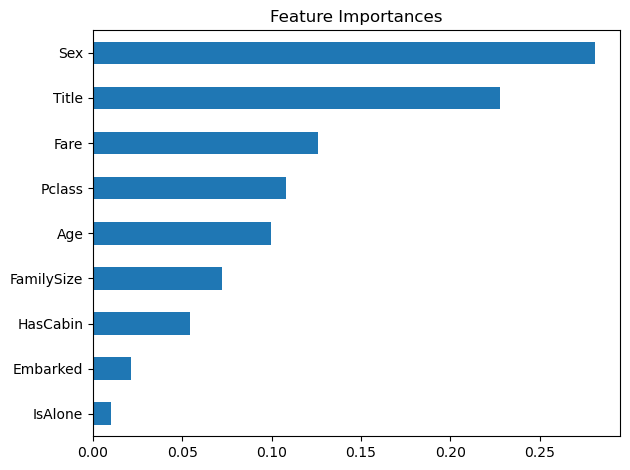

In [5]:
pd.Series(model.feature_importances_, index=FEATURES)\
  .sort_values()\
  .plot(kind='barh', title='Feature Importances')
plt.tight_layout()

## 5. Submission

File naming convention: `submission_<model>_<version>_<lb_score>.csv`
After submitting on Kaggle, actual LB score must be added to the name of the file.

In [7]:
VERSION  = 'v1'
MODEL    = 'rf'

filename = f'../data/submissions/submission_{MODEL}_{VERSION}.csv'

pd.DataFrame({
    'PassengerId': test_ids,
    'Survived':    model.predict(X_test)
}).to_csv(filename, index=False)

print(f'Saved: {filename}')

Saved: ../data/submissions/submission_rf_v1.csv
